### UE ADSP

# Analogical and Digital Signal Processing
# for sensor data

## TP 4 : Algorithme KM - Algorithme EM 

### 1. But du TP 

Le but de ce TP consiste à effectuer un clustering d'un nuage de points créer à partir d'un mélange de gaussiennes bidimensionnelles.

Deux algorithmes seront testés: l'algorithme k-means et l'algorithme EM.

On recherche les paramètres des 2 gaussiennes qui ont été utilisé malheureusement seules sont connues les observations (le nuage de points) sans connaissance de la gaussienne qui l'a généré.

Etapes : 
- construction des données
- programmation et test de l'algorithme k-means
- programmation et test de l'algorithme EM
- changer des paramètres

- Importation des librairies python

In [196]:
import numpy as np
import matplotlib.pyplot as plt

import random

# 2. TP

## 2.1. Création du nuage de points

### 2.1.1 Initialisation des paramètres du mélange de gaussienne

Cette première fonction génère une suite D d’un bruit blanc 2D gaussien avec une puissance égale à $σ^2$. Chaque composante est indépendante.


#### Initialisation des paramètres

$${\displaystyle P ({\boldsymbol {x}},{\boldsymbol {\Phi }})=\sum _{k=1}^{g}\pi _{k}f({\boldsymbol {x}},{\boldsymbol {\theta }}_{k}),}$$

- $\pi_k$ : probabilité d'être dans la classe $k$
- $f({\boldsymbol {x}},{\boldsymbol {\theta }}_{k})$ : loi gaussienne multi-dimensionnel de la classe $k$.

**Loi gaussienne multidimensionnelle**

$${\displaystyle f_{X}\left({\boldsymbol {x}};{\boldsymbol {\mu_k }},{\boldsymbol {\Lambda_k }}\right)={\frac {1}{(2\pi )^{N/2}\det \!\left({\boldsymbol {\Lambda_k }}\right)^{1/2}}}\;\exp \left[-{\frac {1}{2}}\left({\boldsymbol {x}}-{\boldsymbol {\mu_k }}\right)^{\top }{\boldsymbol {\Lambda_k }}^{-1}\left({\boldsymbol {x}}-{\boldsymbol {\mu_k }}\right)\right]}$$

- $N = 2$
- $\boldsymbol {x}$ : vecteur 2d.
- $\boldsymbol {\mu_k}$ : moyenne 2d de la classe $k$.
- $\boldsymbol {\Lambda_k }$ : matrice de covariance $2x2$ de la classe $k$.

Ces deux derniers paramètres suffisent à définir la loi gaussienne.

**Définition de la classe Param**

Cette élément va définir l'ensemble des paramètres d'un mélange de gaussienne.

- définition d'une classe paramètre

- définition d'une fonction générant une suite de points

- variables définissant le mélange de gaussienne  
  - mu1, mu2 : moyennes 2D des classes 1 et 2
  - sigma1, sigma2 : matrice de covariances des classes 1 et 2
  - lambda_coeff : proportion de chacune des 2 classes ($\pi_1$, $\pi_2$)
  - **def initialisation_parametres(self):** fonction effectuant l'initialisation des valeurs des paramètres pour démarrer l'initialisation des paramètres pour l'algorithme EM.

**def initialisation_data_alea_parametres():**

Création d'une variable de class Param (avec comme valeurs celles de __init__)

In [197]:
class Param:
    def __init__(self):
        # valeur de reference
        self.mu1 = np.array([0, 3.5])
        self.mu2 = np.array([3.5, 0])
        self.sigma1 = np.array([[1, 0.2], [0.2, 4]])
        self.sigma2 = np.array([[1, 0.2], [0.2, 1]])
        # self.sigma1inv = np.linalg.inv(self.sigma1)
        # self.sigma2inv = np.linalg.inv(self.sigma2)
        # self.norm1 = np.sqrt(np.linalg.det(self.sigma1))
        # self.norm2 = np.sqrt(np.linalg.det(self.sigma2))
        self.lambda_coef = np.array([0.4, 0.6])
        self.logvraisemblance = 0.

    # nécessaire à l'initialisation de l'algorithme EM
    def initialisation_parametres(self):
        self.mu1 = np.array([1., 1.])
        self.mu2 = np.array([4., 4.])
        self.sigma1 = np.array([[1, 0], [0, 1]])
        self.sigma2 = np.array([[1, 0], [0, 1]])
        # self.sigma1inv = np.linalg.inv(self.sigma1)
        # self.sigma2inv = np.linalg.inv(self.sigma2)
        # self.norm1 = np.sqrt(np.linalg.det(self.sigma1))
        # self.norm2 = np.sqrt(np.linalg.det(self.sigma2))
        self.lambda_coef = np.array([0.5, 0.5])

    def display(self):
        print("mu1 : ", self.mu1)
        print("mu2 : ", self.mu2)
        print("sigma1 : ")
        print(self.sigma1)
        print("sigma2 : ")
        print(self.sigma2)
        # print(self.sigma1inv)
        # print(self.sigma2inv)
        # print(self.norm1)
        # print(self.norm2)
        print("lambda_coef : ", self.lambda_coef)
        print("logvraisemblance : ", self.logvraisemblance)

def initialisation_data_alea_parametres():
    param = Param()
    return param


In [198]:
# nombre de points
nb_points = 200

# generation des donnees aleatoire a partir
# de  2D  distributions gaussienne


# initialisation des parametres du melange de gaussiennes
print("\n **** \n Initialisation")
param_modele = initialisation_data_alea_parametres()
param_modele.display()

labels = np.random.choice([1,0],nb_points, p = param_modele.lambda_coef).reshape(-1,1)
data = labels * np.random.multivariate_normal(param_modele.mu1, param_modele.sigma1, nb_points) + (1-labels) * np.random.multivariate_normal(param_modele.mu2, param_modele.sigma2, nb_points) 

# print("\n **** \n Application de la fonction Initialisation")
# param_modele.initialisation_parametres()
# param_modele.display()


 **** 
 Initialisation
mu1 :  [0.  3.5]
mu2 :  [3.5 0. ]
sigma1 : 
[[1.  0.2]
 [0.2 4. ]]
sigma2 : 
[[1.  0.2]
 [0.2 1. ]]
lambda_coef :  [0.4 0.6]
logvraisemblance :  0.0


## 2.1.2 Génération des données

Définition de la fonction générant un nuage de points aléatoires qui suit un mélange de gaussienne.

On va générer une matrice np.array de taille nbpointsx3

- Les deux premières composantes contiennent les valeurs aléatoires.
- La dernière composante indique le label de la classe de chaque point généré.

Afin d'analyser les résultats, on respectera la proportion de chaque classe lors de la création du nuage de points. 

(Dans la réalité, il faudrait effectuer un tirage aléatoire pour choisir le label, ici on effectue un tirage aléatoire controlé)

- Les nbclasses1 premiers points suivent la loi de la classe 1 donner dans param.
- Les nbclasses2 derniers points suivent la loi de la classe 2 donner dans param.

nbclasses1 + nbclasses2 = nbpoints

nbclasses1 = round(param_data_ale.lambda_coef[0]*nbpoints) (proportion donnée par la probabilité d'être dans la classe 1).
Attention, c'est le nombre théorique dans la réalité on devrait utiliser une loi normale centrée sur ce nombre avec une faible variance.

La fonction fontion suivante permet de générer des échantillons qui suivent une loi gaussienne multi-dimensionnelle.

vous pouvez utiliser [numpy.random.multivariate_normal](https://numpy.org/doc/2.1/reference/random/generated/numpy.random.multivariate_normal.html)

param_data_ale : contient les valeurs des paramètres de la loi.

In [199]:
def generatedataaleatoire(nbpoints: int, param_data_ale: Param) -> np.ndarray:
    # Cette fonction génère des points aleatoire
    # Les coordonnées des points sont générées à partir de
    # 2 distributions gaussiennes de paramètres (mu, sigma)
    # Les points générés avec la premiere gaussienne ont le label 1 les autres le
    # label 2.
    # Nous sommes en train de créer une melange de gaussiennes

    # Entree :
    #    n : nombre de points de chaque cluster

    # Sortie :
    #    d : dataset génére [x y label] (tableau de dimension de taille (n,3))
    #        d[:,2] : label
    #        d[:,0:2] : variables aléatoires 
    #        d[i,0:3] : point i indication de (x,y,label)
    #
    # }

    # determiner le nombre de points dans chque classes
    nbclasses1 = int(round(param_data_ale.lambda_coef[0] * nbpoints))
    nbclasses2 = nbpoints - nbclasses1

    # generation des points
    data = np.zeros((nbpoints, 2))
    data[:nbclasses1, :] = np.random.multivariate_normal(
        param_data_ale.mu1, param_data_ale.sigma1, nbclasses1
    )
    data[nbclasses1:, :] = np.random.multivariate_normal(
        param_data_ale.mu2, param_data_ale.sigma2, nbclasses2
    )

    # labels : 0 pour classe 1, 1 pour classe 2
    labels = np.zeros(nbpoints, dtype=int)
    labels[nbclasses1:] = 1

    d = np.zeros((nbpoints, 3))
    d[:, :2] = data
    d[:, 2] = labels
    
    print("nbpoints : ", nbpoints, ", nbclasses1 : ", nbclasses1, ", nbclasses2 : ", nbclasses2)
    return d

### Tirage aléatoire "contrôlé"

En effet, les classes sont connues.

- Effectuer un tirage aléatoire

- Calculer la moyenne et la matrice de covariance de chacune des 2 classes (heureusement d'avoir classé les variables aléatoires).
(numpy.mean et numpy.cov)


data : contient les données générés.

In [200]:
# generation des points
# Data matrice nb_points x 3
data = generatedataaleatoire(nb_points, param_modele) 

# colcul des moyennes et des matrices de covariances
class_1_data = data[(data[:,2]==0)][:,:2]
class_2_data = data[(data[:, 2]==1)][:,:2]

nbpoints :  200 , nbclasses1 :  80 , nbclasses2 :  120


In [201]:
class_1_mu = np.mean(class_1_data, axis=0)
class_2_mu = np.mean(class_2_data, axis=0)

In [202]:
class_1_cov = np.cov(class_1_data, rowvar=False)
class_2_cov = np.cov(class_2_data, rowvar=False)

- Affichage des données

Afficher un nuage de points où chaque point ayant un même label à la même couleur et chaque label a une couleur différente.

utilisation de np.unique : trouver la liste des labels
numpy.where : trouver les indices qui correspont à un label particulier

[matplotlib.pyplot.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) : affichage d'un nuage de points

On trouve la liste des labels
- En boucle : Pour chaque label
   - trouver les indices du label
   - afficher les points qui correspondent à ces indices

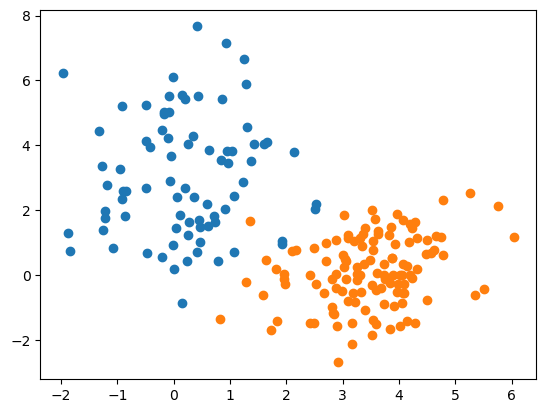

In [204]:
plt.scatter(class_1_data[:,0], class_1_data[:,1])
plt.scatter(class_2_data[:,0], class_2_data[:,1])

In [205]:
import numpy as np
# Initializing the points
point_1 = np.array([[0, 0, 0],[1, 1, 1]])
point_2 = np.array([3, 3, 3])

dist = np.linalg.norm(point_1-point_2,axis=1)
print(point_1-point_2)
print(dist)

[[-3 -3 -3]
 [-2 -2 -2]]
[5.19615242 3.46410162]


- On vient d'afficher la référence

- On effectue une copie de data (data_r)(*numpy.ndarray.copy*).
- Maintenant, cette copie perd sa labelisation. Pour cela, on effectue une labélisation à l'aide d'un tirage aléatoire du label (la composante 2).

*np.random.randint* appliqué sur la totalité de la composante 2


Puis afficher le résultat obtenu
 


nbpoints :  200 , nbclasses1 :  80 , nbclasses2 :  120


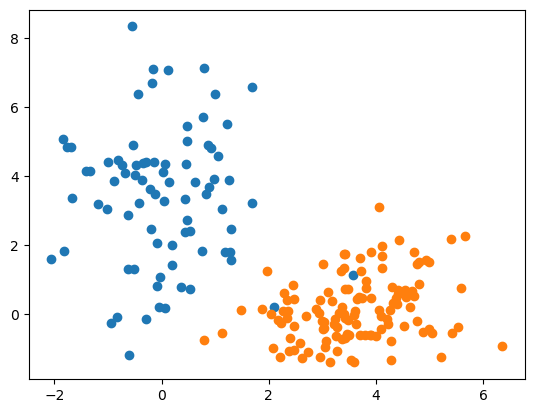

In [206]:
# reinitialisation des labels (nbre aleatoire egal a 1 ou 2

# copie de data sur data_r
data_r = generatedataaleatoire(nb_points, param_modele) 

#np.random.shuffle(data_r[:,2])

# modification des labels de data_r de manière aléatoire

# affichage de data_r
class_1_data = data_r[(data_r[:,2]==0)][:,:2]
class_2_data = data_r[(data_r[:, 2]==1)][:,:2]

plt.scatter(class_1_data[:,0], class_1_data[:,1])
plt.scatter(class_2_data[:,0], class_2_data[:,1])

## 2.2. Clustering à l'aide de l'algorithme k-means

### 2.2.1 Description de l'algorithme k-mean

Choisir k points qui représentent la position moyenne des partitions $m_1(1), …, m_k(1)$ initiales (au hasard par exemple) ;

Répéter jusqu'à ce qu'il y ait convergence (les centres de changent plus ou le nombre limite d'itération est atteint):

– affecter chaque observation à la partition la plus proche (c.-à-d. effectuer une partition en fonction des distances aux centres de chaque classe) :

$${\displaystyle S_{i}^{(t)}=\left\{\mathbf {x} _{j}:{\big \|}\mathbf {x} _{j}-\mathbf {m} _{i}^{(t)}{\big \|}\leq {\big \|}\mathbf {x} _{j}-\mathbf {m} _{i^{*}}^{(t)}{\big \|}\ \forall \ i^{*}=1,\ldots ,k\right\}}$$

– mettre à jour la moyenne de chaque cluster :

$${\displaystyle \mathbf {m} _{i}^{(t+1)}={\frac {1}{|S_{i}^{(t)}|}}\sum _{\mathbf {x} _{j}\in S_{i}^{(t)}}\mathbf {x} _{j}}.$$

**Fonction k_means(k,data_input)**


- Input
    - k : nombre de clusters
    - data_input : matrice n x m - $n$ points de dimension $m$
    - visu_fig : si True - affichage des figures indiquant la labelisation des points

- Output args: 
    - label : matrice 1 x n array avec des valeurs comprises dans $0,\cdots ,k-1$ représentant à quel cluster appartient le point
    - centre : matrice m x k : $k$ centres de dimension $m$ qui représentent les centres de chaque cluster


In [207]:
def k_means(k, data_input, visu_fig):
    # Algorithme des k-Means - labelisé les donnees en k clusters.
    #   Input args: k: nombre de clusters
    #   data_input: matrice m x n  n points de dimension m
    #   Output args: label: matrice 1 x n array avec des valeurs comprises
    #   dans 0,...,k-1 représentant a quel cluster appartient le point
    #   centre: matrice m x k de dimension m représentant les centres de chaque
    #   cluster



    # -------
    # Initialisation des centres au hasard
    # -------
    # Choisir au hasard k centres pour initialiser le processus

    # il faut deux points tires au hasard
    # ici on prend k points au hasard dans la liste des points
    # choisir aléatoirement k indices uniques entre 1 et nbPoints
    # print(data_input.shape)
    

    
    #randIndices = randperm(nbPoints,k);
    # initialisation des centroïdes à partir de k points
    centr_idx = np.random.choice(len(data_input), k)
    
    centres = data_input[(centr_idx)]
    prev_centres = centres.copy()
    print("centre ", centres)
    # Répéter tant que la labélisation entre 2 iterations changent
    # on peut tester les labels
    # ou la position des centres

    # initialisation de labels
    label = np.random.choice([0,1], len(data_input))

    # initialisation de labels et des centres de l'etape n-1 (for stopping criterion)
    labelPrev = label

    # -----
    # iteration jusqu'à stop is true
    # ---
    # compteur iteration
    iterations = 0
    eps = 1e-5

    # critere d'arret initialise a false
    stop = False  # il est mis a true si le test d'arret est true

    while stop is False:
        print("iter ", iterations)
        dists = (data_input.reshape(200,2,1) - centres.reshape(k,2).transpose(1,0))
        norms = np.linalg.norm(dists,axis=1)
        new_labels = np.argmin(norms, axis=1)
        #print(data_input[0] - centres[1])
        #print("---------")
        #print(dists)
        #print(np.sum(new_labels==0))
        #print(data_input[(new_labels==0)])
        prev_centres = centres.copy()

        for i in range(k): 
            label_k = data_input[(new_labels==i)]
            centres[i] = np.mean(label_k, axis=0)

            
        label = new_labels
        
        
        
        if visu_fig:
            fig, ax = plt.subplots()

            for g in np.unique(label[:]):
                i = np.where(label[:] == g)
                ax.scatter(data_input[i, 0], data_input[i, 1], label=g)
            plt.scatter(centres[0, 0], centres[0, 1], marker = 'x', linewidths=3)
            plt.scatter(centres[1, 0], centres[1, 1], marker = 'x', linewidths=3)
            plt.plot(centres[:, 0], centres[:, 1])

            plt.show()
                # Recalculer la position des centres en fonction de la labelisation
        # qui vient d'etre faite

        # -----
        # recalcul des centres en fonction de la nouvelle labelisation
        # ---
        # pour chaque cluster déterminer son centre, ici k = 2

        # Test sur le changement de position des centres
        # selon votre preference

        # calcul de la variable d'arrêt

        iterations = iterations + 1
        
        if iterations > 100 or np.linalg.norm(prev_centres - centres) < eps: 
            stop = True

        

    print("k_Means.m utilise", iterations, "itérations \n")

    return label, centres

### 2.2.2 Utilisation de l'algorithme k-means
Application de k_means (pour k = 2)

On peut essayer d'augmenter la valeur de $k$

centre  [[ 1.87563144  0.16183872]
 [-0.62916631  1.30040948]]
iter  0


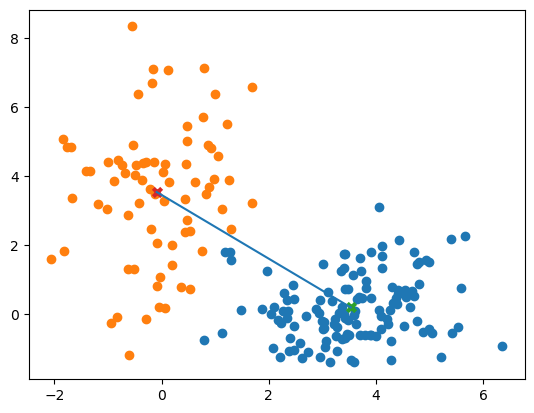

iter  1


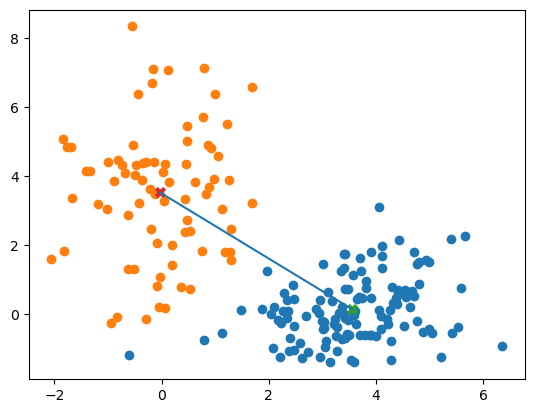

iter  2


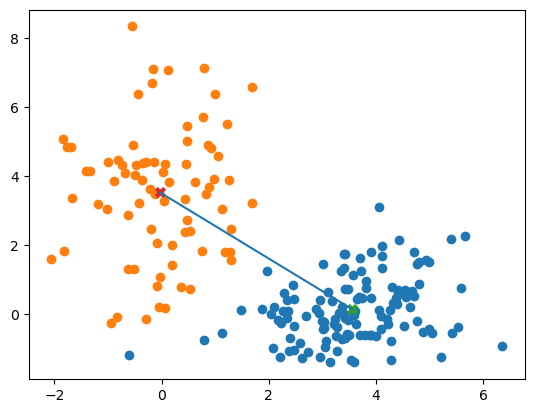

k_Means.m utilise 3 itérations 



In [208]:
k = 2

data_label, centres = k_means(k, data_r[:,0:2], True)

In [209]:
print(f"The precision of classification is: {(data_label == 1-data_r[:,2]).mean()*100} %")

The precision of classification is: 98.5 %


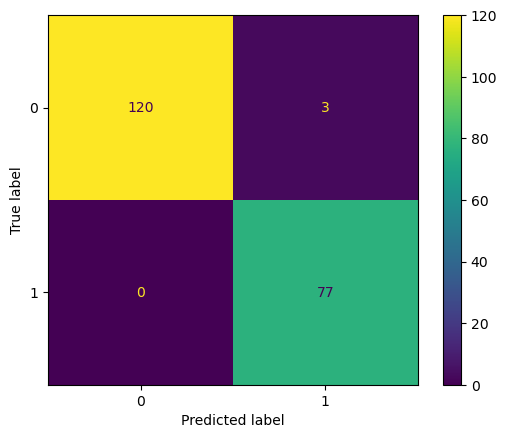

In [211]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(data_label,1-data_r[:,2])

- On remarque la matrice de confusion presente des valuer diagonale élevé comparé au autre l'algorithme a bien fonctionné pour ce jeu de données spécifique.

Description, analyse et commentaire

(on peut essayer d'estimer les paramètres du mélange de gaussienne à partir du résultat du k-means)

(il peut être conseillé de faire varier les points d'initialisation, le nombre de classe, de regarder la vitesse de convergence,...)

## 2.3 Algorithme EM

### 2.3.1 Détermination des fonctions prob, calc_varlogvraisemblance et calc_distance

**def prob(point, mu, sigma, lambda_coef):**

point : correspond à l'ensemble des points dont on cherche la probilité



- calcul de $𝑃(𝑋_𝑖|_{𝑍_𝑖=𝑗})𝑃(𝑍_𝑖=𝑗)$
  - ${\displaystyle P(X_i|_{𝑍_𝑖=𝑗})={\frac {1}{(2\pi )^{N/2}\det \!\left({\boldsymbol {\Lambda }}\right)^{1/2}}}\;\exp \left[-{\frac {1}{2}}\left({\boldsymbol {x}}-{\boldsymbol {\mu }}\right)^{\top }{\boldsymbol {\Lambda }}^{-1}\left({\boldsymbol {x}}-{\boldsymbol {\mu }}\right)\right]}$
  - $𝑃(𝑍_𝑖=𝑗)$ correspond à lambda_coef
  - mu et sigma correspondent aux paramètres de la loi $𝑃(𝑋_𝑖|_{𝑍_𝑖=𝑗})$ appliqué à point.

- mu est de dimension 1x2 $\mu_j$
- sigma de dimension 2x2, matrice de covariance du cluster $j$
- lambda_coef est un scalaire ($𝑃(𝑍_𝑖=𝑗)$) : probabilité d'être dans le cluster $j$

- Input
  - point : ensemble des points dont on cherche la probabilité
  - mu : vecteur moyenne du cluster $j$
  - sigma : matrice de covariance du cluster $j$
  - lambda_coef : probabilité du cluster $j$
- Output
  - p : resultat du calculde probabilité


**def calc_varlogvraisemblance(param, param_):**

Calcul de la variation du logvraisemblance

- Input
  - param et param_ : les paramètres à comparer
    - param.logvraisemblance indique le logvraisemblance

- Output
  - d : distance

**def calc_distance(param, param_):** 

On calcule la somme des déplacement des moyennes de chaque cluster entre les 2 classes

$$d=\sum_{i=1}^2{||param.\mu_i-param_.\mu_i||^2}$$

- Input
  - param et param_ : les paramètres à comparer

- Output
  - d : distance


In [212]:
def prob(point, mu, sigma, lambda_coef):
    # Calcul de la probabilite / vraisemblance
    # Probabilite qui est donne par une suite de parametres \theta pour les PDF
    # des donnees observees. Cela revient a calculer la vraisemblance des
    # parametres \theta des points X.
    #
    # point = [x y]
    # mu = 1x2
    # sigma = 2x2
    # lambda = 1x2
    # sigma est carre (actuallement semi definite positive)
    # input:
    # point coordonn?es
    # mu : moyenne
    # sigma : matrice covariance
    # lambda proportion entre les 2 classes vu par le cluster considere
    # }
    # p = lambda;
    # utilise le fait que chaque composante est indépendante
    # for ii = 1:length(point)
    #    p = p * normpdf(point(1,ii), mu(1,ii), sigma(ii,ii));
    # end
    # print("tt")
    # print("p", point, "m", mu, "s", sigma, "l", lambda_coef)
    # print("t")
    point = np.atleast_2d(point)   # force (n,d)

    d = mu.shape[0]                 # dimension (ici 2)

    sigma_inv = np.linalg.inv(sigma)
    det_sigma = np.linalg.det(sigma)

    diff = point - mu               # (n,d)

    # terme exponentiel pour chaque point
    exponent = -0.5 * np.sum((diff @ sigma_inv) * diff, axis=1)

    # constante de normalisation
    normalisation = 1 / np.sqrt((2*np.pi)**d * det_sigma)

    gaussian = normalisation * np.exp(exponent)

    # multiplication par la proportion du cluster
    p = lambda_coef * gaussian      # (n,)

    return p

In [213]:
def calc_distance(param, param_):
    # {
    # Cette fonction calcule la distance entre 2 suites de param?tres (c'est-?-dire
    # l'evolution de la position des moyennes)

    # Input:
    #    Param : parametres precedents
    #   Param_: parametres couarnts

    # Output:
    #    d: distance semi-euclidienne
    # %}
    d = (np.linalg.norm(param.mu1 - param_.mu1) ** 2
         + np.linalg.norm(param.mu2 - param_.mu2) ** 2)
    
    return d

#calc_varlogvraisemblance(np.random.rand(2,2), np.random.rand(2,2))

### 2.3.2 Expectation


Partie E de l'algorithme EM.

$$\omega_𝑖^𝑗=P(𝑍_𝑖=𝑗|_{𝑋_𝑖};\phi,\mu,\Sigma)=\frac{𝑃(𝑋_𝑖|_{𝑍_𝑖=𝑗})𝑃(𝑍_𝑖=𝑗)}{\sum_{𝑙=1}^𝑘{𝑃(𝑋_𝑖|_{𝑍_𝑖=l})𝑃(𝑍_𝑖=𝑙)}}$$

Ce résultat est stocké dans p_cluster

**def expectation(data, param):**

- Entree:
  - Data : nx3 (number of data points , [x, y, label])
  - Param: (mu, sigma, lambda)

- Sortie:
  - Data: dataset avec une valeur de label mise a jour
  - p_cluster : probabilite d'appartenir a chaque cluster
  



In [214]:
def expectation(data, param,visu_label = False):
    # {
    # Cette fonctgion calcule la premiere ?taoe de l'algorithme EM : expectation.
    # Il calcul la probabilit? de chaque point d'appartenir ? chaque cluster.
    # Puis il relabelise les donn?es en fonction de ces probabilit?.

    # Entree:
    #    Data : nx3 (number of data points , [x, y, label])
    #    Param: (mu, sigma, lambda)

    # Sortie:
    #    Data: dataset avec une valeur de label mise ? jour
    #    p_cluster : probaabilite d'appartenir a chaque cluster
    # 
    p_cluster = np.zeros((data.shape[0], 4))
    for ii in range(0, data.shape[0]):
        # lecture du points
        x = data[ii, 0:2].reshape(1,-1)

        # calcul de la probabilite d'appartenir a chaque cluster
        p_cluster[ii, 0] = prob(x, param.mu1, param.sigma1, param.lambda_coef[0]).item()
        p_cluster[ii, 1] = prob(x, param.mu2, param.sigma2, param.lambda_coef[1]).item()

        # normalisation des probabilites    
        p_cluster[ii, 2] = p_cluster[ii, 0] / (p_cluster[ii, 0] + p_cluster[ii, 1])
        p_cluster[ii, 3] = p_cluster[ii, 1] / (p_cluster[ii, 0] + p_cluster[ii, 1])

        
    if visu_label is True:
        plt.figure()
        fig, ax = plt.subplots()
        
        for g in np.unique(data[:, 2]):
            i = np.where(data[:, 2] == g)
            ax.scatter(data[i, 0], data[i, 1], label=g)
            plt.plot([param.mu1[0], param.mu2[0]], [param.mu1[1], param.mu2[1]])
        plt.scatter(param.mu1[0], param.mu1[1], marker = 'x', linewidths=3)
        plt.scatter(param.mu2[0], param.mu2[1], marker = 'x', linewidths=3)
        plt.show()

    return data, p_cluster

### 2.3.3. Maximisation

Etape M de l'algorithme EM

On met à jour les lois

$$\phi_𝑗=\frac{1}{𝑁}\sum_{𝑖=1}^𝑁{\omega_𝑖^𝑗}$$ 

(qui correspond aux coef_lambda)

Les 2 paramètres suivant correspondent aux paramètres des lois de chaque classes.

$$\mu_𝑗=\frac{\sum_{𝑖=1}^𝑁{\omega_𝑖^𝑗 𝑋_𝑖}}{(\sum_{𝑖=1}^𝑁{\omega_𝑖^𝑗}}$$

$$\Sigma_𝑗=\frac{\sum_{i=1}^𝑁{\omega_𝑖^𝑗 (𝑋_𝑖−\mu_𝑗)^𝑡 (𝑋_𝑖−\mu_𝑗 )}}{\sum_{𝑖=1}^𝑁{\omega_𝑖^𝑗}}$$

In [215]:
def maximisation(data, param_, p_cluster):
    # Cette fonction est la deuxième etape de l'algo EM : maximisation
    # Elle permet de mettre a jour les paramètres des distributions gaussiennes
    # du nouveau dataset.

    # Entree:
    #    Data : nx3 (number of data points , [x, y, label])
    #    Param: (mu, sigma, lambda)

    # Sortie:
    #    Param: paramètres mise a jour

    param_ = Param()   # ← NOUVEL objet

    # détermination de la probilité de chacun des classes
    N = data.shape[0]
    X = data[:, 0:2]

    # responsabilités
    omega1 = p_cluster[:, 2]
    omega2 = p_cluster[:, 3]

    # ------------------------
    # Mise à jour des proportions
    # ------------------------
    percent_cluster1 = np.sum(omega1)
    percent_cluster2 = np.sum(omega2)

    # % calcul mise à jour des proportions
    param_.lambda_coef[0] = percent_cluster1 / N
    param_.lambda_coef[1] = percent_cluster2 / N

    # % calculer de la moyenne
    param_.mu1 = np.sum(omega1[:, None] * X, axis=0) / percent_cluster1
    param_.mu2 = np.sum(omega2[:, None] * X, axis=0) / percent_cluster2

    # % calculer la variance
    diff1 = X - param_.mu1
    diff2 = X - param_.mu2

    param_.sigma1 = (omega1[:, None] * diff1).T @ diff1 / percent_cluster1
    param_.sigma2 = (omega2[:, None] * diff2).T @ diff2 / percent_cluster2

    p1 = prob(X, param_.mu1, param_.sigma1, param_.lambda_coef[0])
    p2 = prob(X, param_.mu2, param_.sigma2, param_.lambda_coef[1])

    param_.logvraisemblance = float(np.sum(np.log(p1 + p2)))

    # print("maximis")
    param_.display()
    return param_

### 2.2.4. EM



In [231]:
def em(data, param):
    # {
    # Fonction principale de l'algorithme EM.
    # On retrouve l'etape de Expectatiopn et celle de mximisation.
    # Le processus est un processus iteratif qui est stope lorsqu'un certain
    # seuil d'erreur est atteint (variation entre 2 iterations).

    # Entree:
    #    Data: dataset incluat les points et les labels [x y label]
    #    Param: parametres des distributions gaussiennes (mu, sigma, lambda)

    # Sortie:
    #    Data_f: dataset avec leslabels mise a jour
    #    Param_f: parametres finaux vers lesquels a converge l'algorithme EM
    # %}
    print("EM")
    print("Modele (initialisé)")
    param.display()

    param_ = Param()

    

    shift = 10000  # initialisation représente la variation du logvraisemblance entre 2 itérations successives
    iterations = 1       # compteur iter (que l'on peut controler dans la boucle)
    epsilon = 0.01  # precision

    while shift > epsilon and iterations < 100:
        # E-step
        data_, p_cluster = expectation(data, param)


        # M-step
        param_ = maximisation(data_, param, p_cluster)

        # calcul de la distance/erreurr entre 2 valeurs de param succcessifs
        shift = calc_distance(param, param_)

        # print(Param_.sigma1(1,1), Param_.sigma2(1,1));
        # print(Param_.lamda(1), Param_.lamda(2));
        data = data_
        param = param_
        
        iterations = iterations + 1

    print("iterations : ",iterations)
    data_f = data
    param_f = param
    return data_f, param_f

## 2.3.5 Mise en oeuvre de l'algotrithme EM

Le mélange de gaussienne est initalisé en considérant que :
- les classes sont équiprobables
- les matrices de covariances est la matrice identité
- les moyennes ont pour valeurs resp. $[1., 1.]$ et $[4.,4.]$

Modèle
mu1 :  [0.  3.5]
mu2 :  [3.5 0. ]
sigma1 : 
[[1.  0.2]
 [0.2 4. ]]
sigma2 : 
[[1.  0.2]
 [0.2 1. ]]
lambda_coef :  [0.4 0.6]
logvraisemblance :  0.0
EM
Modele (initialisé)
mu1 :  [1. 1.]
mu2 :  [4. 4.]
sigma1 : 
[[1 0]
 [0 1]]
sigma2 : 
[[1 0]
 [0 1]]
lambda_coef :  [0.5 0.5]
logvraisemblance :  0.0
mu1 :  [1.98404869 0.83410592]
mu2 :  [2.82507071 2.96599024]
sigma1 : 
[[ 3.22243219 -2.05814923]
 [-2.05814923  2.98413365]]
sigma2 : 
[[ 3.63424434 -3.56475811]
 [-3.56475811  4.58744359]]
lambda_coef :  [0.7882225 0.2117775]
logvraisemblance :  -793.0322670629488
mu1 :  [2.06792383 0.80345284]
mu2 :  [2.51963002 3.11454962]
sigma1 : 
[[ 3.25614631 -1.86120768]
 [-1.86120768  2.76624386]]
sigma2 : 
[[ 3.91708067 -3.72615523]
 [-3.72615523  4.84802753]]
lambda_coef :  [0.79138121 0.20861879]
logvraisemblance :  -788.7574912260372
mu1 :  [2.14808458 0.74994133]
mu2 :  [2.21489344 3.29271768]
sigma1 : 
[[ 3.26436774 -1.67697058]
 [-1.67697058  2.51661804]]
sigma2 : 
[[ 4.03627204 -3.

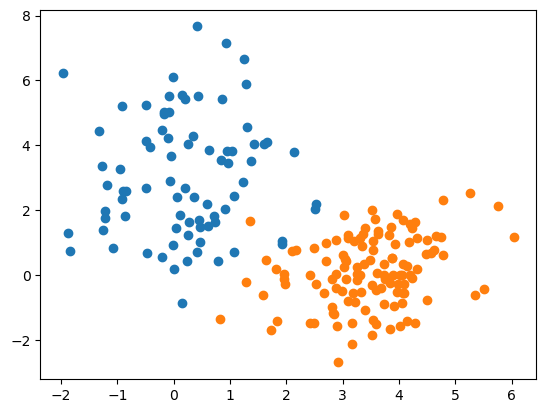

Modele
mu1 :  [0.  3.5]
mu2 :  [3.5 0. ]
sigma1 : 
[[1.  0.2]
 [0.2 4. ]]
sigma2 : 
[[1.  0.2]
 [0.2 1. ]]
lambda_coef :  [0.4 0.6]
logvraisemblance :  0.0
Estime
mu1 :  [3.42927957 0.15778926]
mu2 :  [0.13071719 3.09367584]
sigma1 : 
[[0.87480451 0.22002144]
 [0.22002144 1.15207505]]
sigma2 : 
[[0.81969219 0.20211517]
 [0.20211517 3.47182671]]
lambda_coef :  [0.61585649 0.38414351]
logvraisemblance :  -730.4204551606297


In [248]:
param_modele = initialisation_data_alea_parametres()
print("Modèle")
param_modele.display()

# initialisation des lois pour demarrer l'algorithme EM
param_init = Param()
param_init.initialisation_parametres()

data_r = data.copy()
data_r[:, 2] = np.random.randint(low=1, high=3, size=nb_points)

data_f, param_f = em(data_r, param_init)

fig, ax = plt.subplots()
for g in np.unique(data[:,2]):
    i = np.where(data[:,2] == g)
    ax.scatter(data[i,0], data[i,1], label=g)

plt.show()

print("Modele")
param_modele.display()
print("Estime")
param_f.display()

- L'erreur relatif entre les paramètres du modèle de référence et ceux estimés est relativement faible, ce qui suggère que l'algorithme a bien fonctionné pour ce jeu de données spécifique.

In [249]:
param_f.mu1[0], param_f.mu1[1] = param_f.mu1[1], param_f.mu1[0]
param_f.mu2[0], param_f.mu2[1] = param_f.mu2[1], param_f.mu2[0]

In [250]:
print("Erreur relative pour mu1 : ", np.linalg.norm(param_modele.mu1 - param_f.mu1) / np.linalg.norm(param_modele.mu1))
print("Erreur relative pour mu2 : ", np.linalg.norm(param_modele.mu2 - param_f.mu2) / np.linalg.norm(param_modele.mu2))
print("Erreur relative pour sigma1 : ", np.linalg.norm(param_modele.sigma1 - param_f.sigma1) / np.linalg.norm(param_modele.sigma1))
print("Erreur relative pour sigma2 : ", np.linalg.norm(param_modele.sigma2 - param_f.sigma2) / np.linalg.norm(param_modele.sigma2))
print("Erreur relative pour lambda : ", np.linalg.norm(param_modele.lambda_coef - param_f.lambda_coef) / np.linalg.norm(param_modele.lambda_coef))  

Erreur relative pour mu1 :  0.04940365183742521
Erreur relative pour mu2 :  0.12195225177847231
Erreur relative pour sigma1 :  0.6898032920624652
Erreur relative pour sigma2 :  1.7184584908010494
Erreur relative pour lambda :  0.4233293980043442


Décrire, analyser et commenter

(on peut faire varier les initialisations, les lois du nuages de points de départ,étudier la vitesse de convergence, le nombre de points, ...)